In [1]:
!pip install -q --upgrade ultralytics

import importlib
import ultralytics
importlib.reload(ultralytics)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


<module 'ultralytics' from '/usr/local/lib/python3.12/dist-packages/ultralytics/__init__.py'>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'smoke-fire-detection-yolo' dataset.
Path to dataset files: /kaggle/input/smoke-fire-detection-yolo


In [3]:
import os
import shutil

src = f"{path}/data"
dst = "/kaggle/working/firesmoke"

for split in ["train", "val", "test"]:
    for folder in ["images", "labels"]:
        src_path = os.path.join(src, split, folder)
        dst_path = os.path.join(dst, split, folder)

        os.makedirs(dst_path, exist_ok=True)

        for file in os.listdir(src_path):
            shutil.copy(
                os.path.join(src_path, file),
                os.path.join(dst_path, file)
            )

In [4]:
import os
import random
import shutil
from collections import defaultdict

src = "/kaggle/working/firesmoke"
dst = "/kaggle/working/firesmoke_balanced"

for split in ["train", "val", "test"]:
    print(f"\n🔹 Processing {split}...")

    img_src = os.path.join(src, split, "images")
    lbl_src = os.path.join(src, split, "labels")

    img_dst = os.path.join(dst, split, "images")
    lbl_dst = os.path.join(dst, split, "labels")

    os.makedirs(img_dst, exist_ok=True)
    os.makedirs(lbl_dst, exist_ok=True)

    class_to_files = defaultdict(list)

    for file in os.listdir(lbl_src):
        label_path = os.path.join(lbl_src, file)

        classes = set()

        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                try:
                    class_id = int(parts[0])
                    classes.add(class_id)
                except:
                    continue

        img_file = file.replace(".txt", ".jpg")


        if not os.path.exists(os.path.join(img_src, img_file)):
            continue

        for c in classes:
            class_to_files[c].append(img_file)


    min_count = min(len(v) for v in class_to_files.values())
    print("Min samples per class:", min_count)

    selected_images = set()

    for c, files in class_to_files.items():
        sampled = random.sample(files, min_count)
        selected_images.update(sampled)

    print("Total selected images:", len(selected_images))

    for img in selected_images:
        src_img_path = os.path.join(img_src, img)
        src_lbl_path = os.path.join(lbl_src, img.replace(".jpg", ".txt"))

        shutil.copy(src_img_path, os.path.join(img_dst, img))
        shutil.copy(src_lbl_path, os.path.join(lbl_dst, img.replace(".jpg", ".txt")))

print("\n✅ Balancing fertig!")


🔹 Processing train...
Min samples per class: 3828
Total selected images: 5949

🔹 Processing val...
Min samples per class: 879
Total selected images: 1363

🔹 Processing test...
Min samples per class: 1115
Total selected images: 1755

✅ Balancing fertig!


In [5]:

from ultralytics import YOLO



data_yaml_content = """
train: train/images
val: val/images
test: test/images

nc: 2  # Number of classes (assuming smoke and fire)
names: ['smoke', 'fire'] # Class names
"""

# Define the path where the YAML file will be created
yaml_dir = "/kaggle/working/firesmoke_balanced"
yaml_path = os.path.join(yaml_dir, "dataset.yaml")

# Ensure the directory exists (it should from previous steps)
os.makedirs(yaml_dir, exist_ok=True)

# Write the YAML content to the file
with open(yaml_path, 'w') as f:
    f.write(data_yaml_content)

print(f"Dataset YAML file created at: {yaml_path}")

# Starte mit vortrainierten
model = YOLO("yolo26n.pt")

# "kurzes" Training
results = model.train(data=yaml_path, epochs=50, imgsz=640, batch=16, fraction=1.0, patience=15)#device=0 for gpu

Dataset YAML file created at: /kaggle/working/firesmoke_balanced/dataset.yaml
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/firesmoke_balanced/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train,

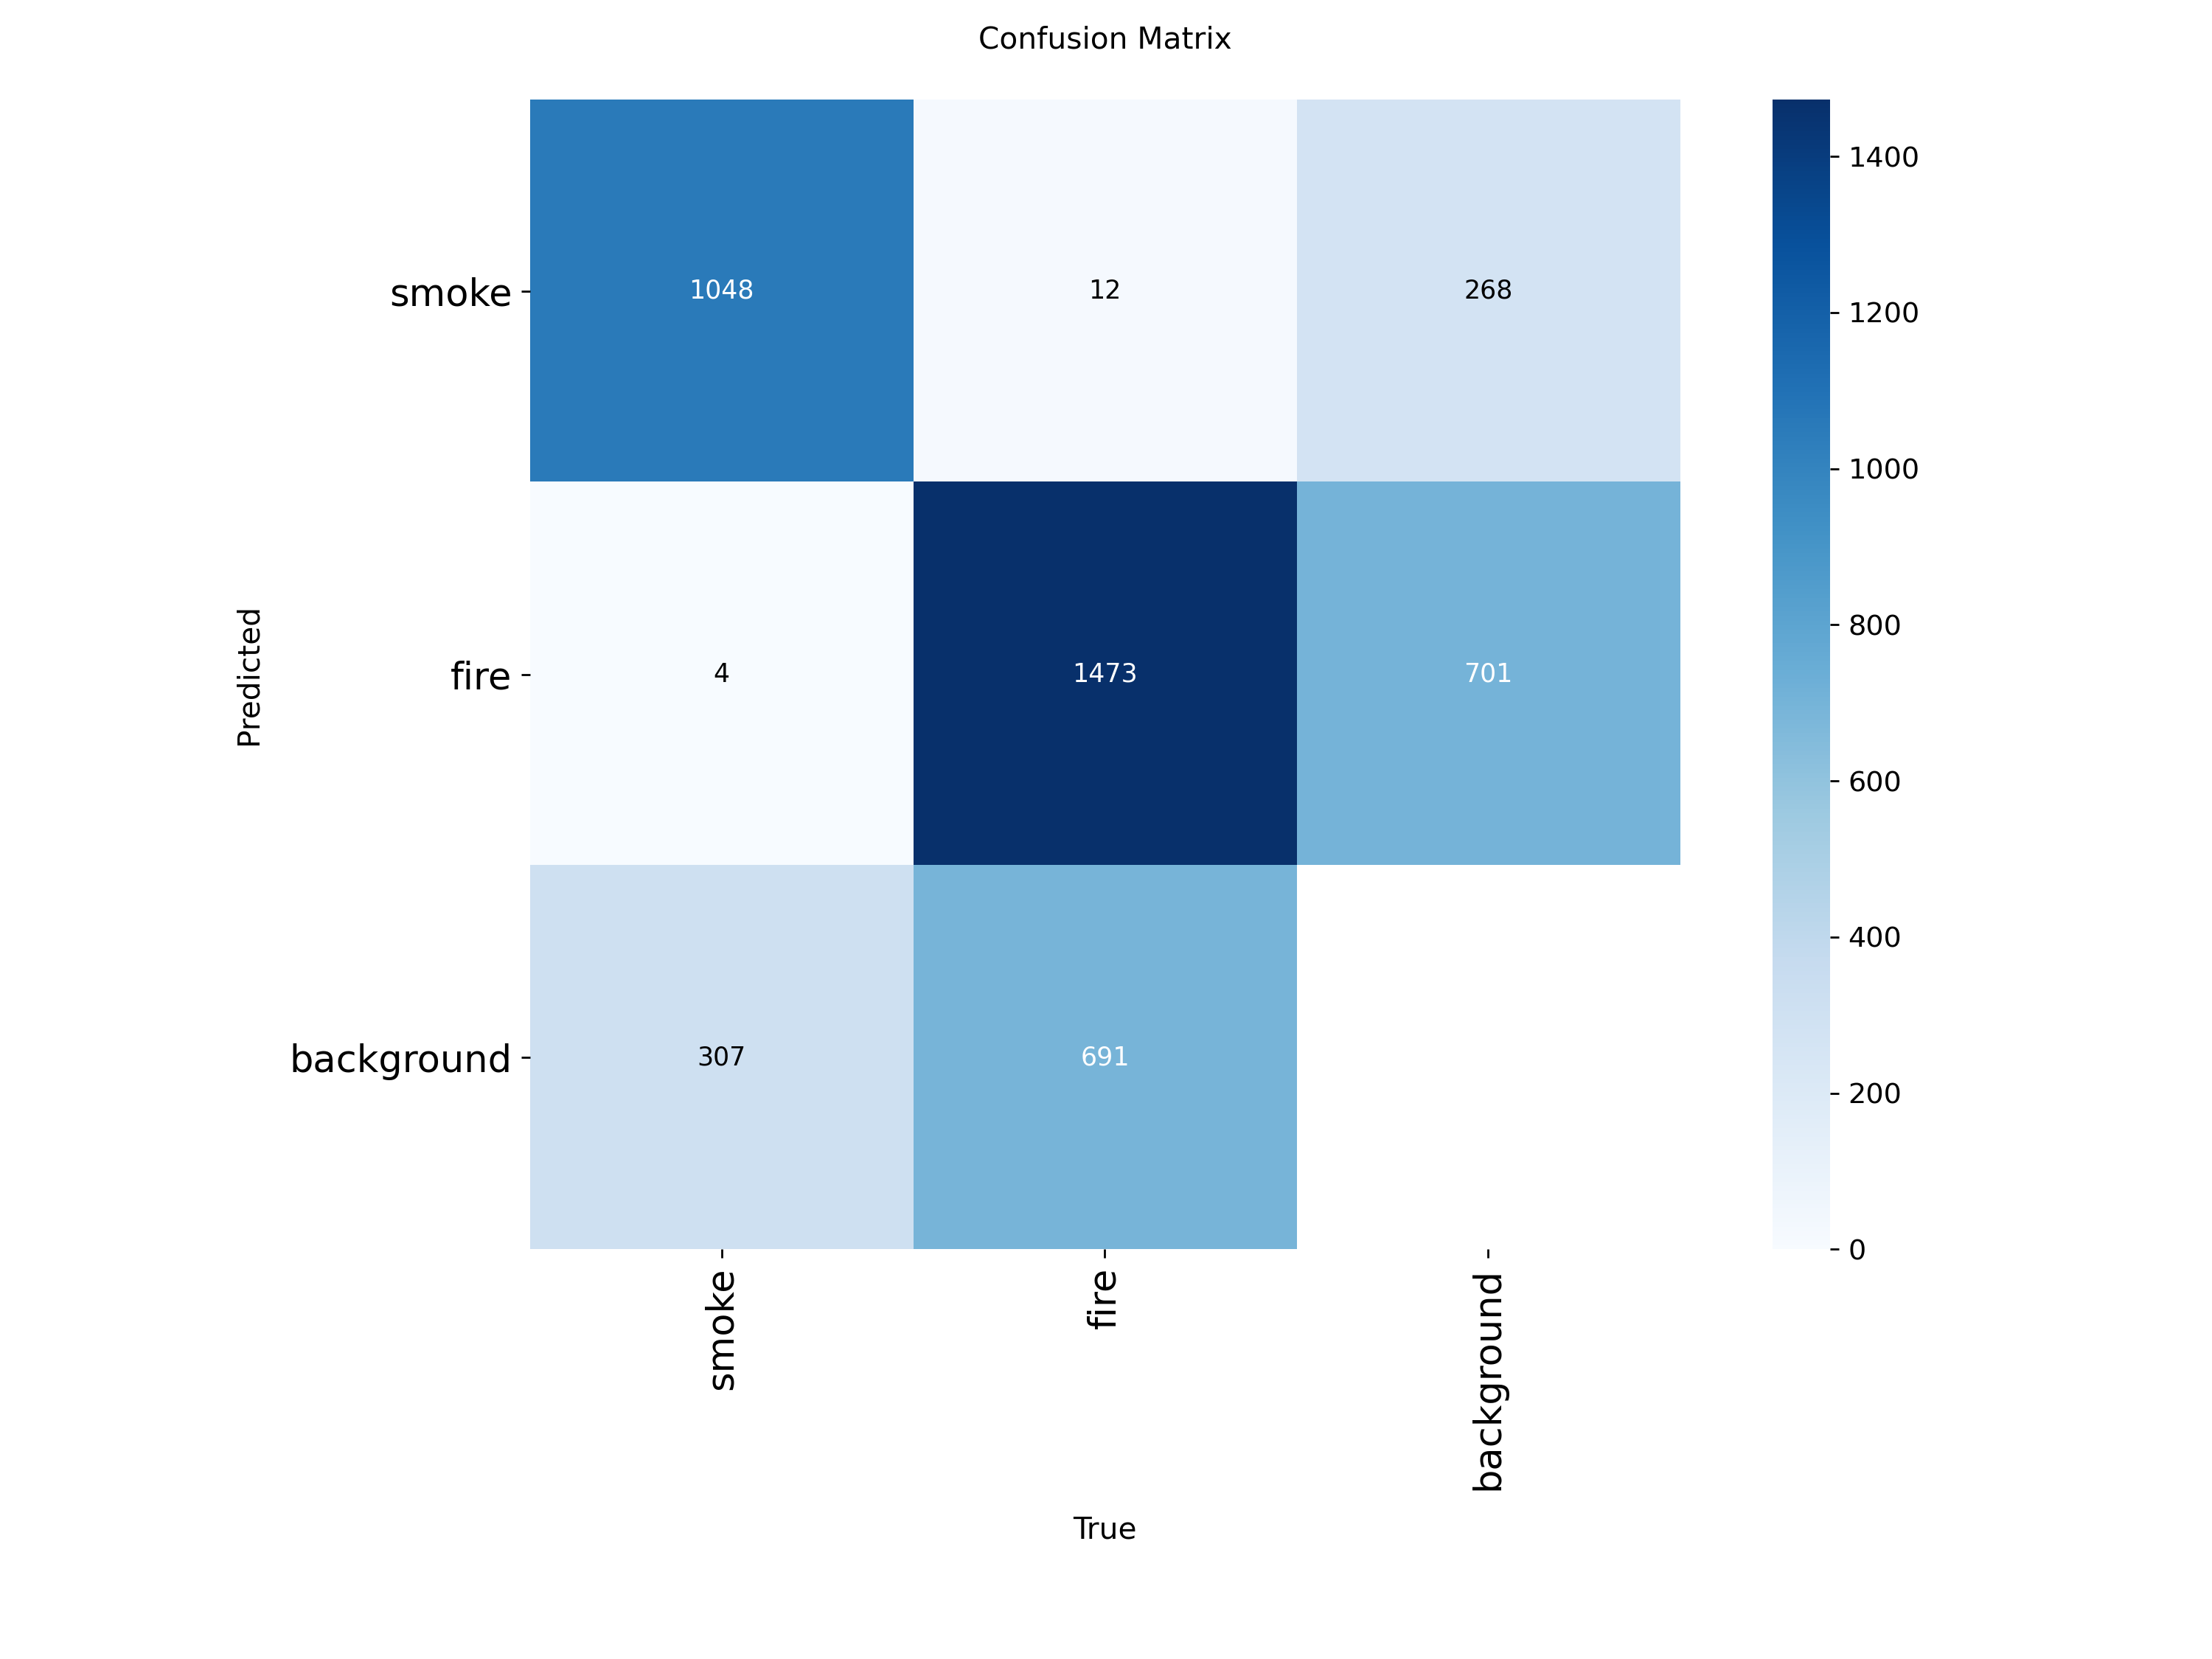